<a href="https://colab.research.google.com/github/AmalKhaled28/Social-Media-Analytics-/blob/main/Social_Media_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install praw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 3.5 MB/s eta 0:00:00


#Connect to Reddit Using PRAW Library

In [ ]:
import praw

# sets up your Reddit API
reddit = praw.Reddit(
    client_id='rLxTHWqSGM7gdvmJg0GeyQ',  # client ID
    client_secret='nGbZQ2AQLFEKcW7XFUoI8br4XpPZFA',  #secret
    user_agent='Starbucks Data Analysis by Wild-Web2654'
)

# Test the connection
print(reddit.read_only)

True


#Collect Data from Reddit

In [ ]:
import pandas as pd
from datetime import datetime  # Import the datetime module


# Define subreddit (starbucks) and fetch posts
subreddit = reddit.subreddit("Starbucks")
posts = []

for post in subreddit.hot(limit=50):  # Fetch top 50 posts
    if post.selftext and isinstance(post.selftext, str):  # Ensure valid text
      posts.append({
          "content": post.selftext,
          "user": post.author.name if post.author else 'Anonymous',
          "date": datetime.utcfromtimestamp(post.created_utc).strftime('%Y-%m-%d %H:%M:%S')
        })


# Save the data to a structured CSV file
df = pd.DataFrame(posts)
df.to_csv("starbucks_posts.csv", index=False)
print("Data saved to starbucks_posts.csv")

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Data saved to starbucks_posts.csv


# Text Processing

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')



# Preprocessing function
def preprocess_text(text):
    # Remove URLs, special characters
    text = re.sub(r"http\S+|@\S+|#\S+|[^A-Za-z\s]|\d", "", text)
    # Convert to lowercase
    text = text.lower()

    # Tokenize text
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    # Lemmatize tokens
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)


# Apply preprocessing
df['processed_content'] = df['content'].apply(preprocess_text)

# Save preprocessed data for further use
df.to_csv("preprocessed_starbucks_data.csv", index=False)
print("Preprocessing complete.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Preprocessing complete.


In [ ]:
df.head()

,content,user,date,processed_content,sentiment
0,"I see way to many people defending Starbucks ""...",Doesntmatter1237,2024-12-04 17:43:22,see way many people defending starbucks fault ...,Positive
1,It’s Holiday season!! \nWhy haven’t they broug...,PolyNamo_48,2024-12-04 19:48:14,holiday season havent brought back yet,Positive
2,Anybody work at this store?,s6ash9a,2024-12-05 01:45:23,anybody work store,Neutral
3,This is NOT okay. So many of my partners are s...,Important_Process372,2024-12-05 03:01:43,okay many partner struggling didnt get paid to...,Positive
4,Why? This is the second time this ever happene...,Hot_Butterscotch1200,2024-12-04 17:29:36,second time ever happened working customer tod...,Positive


#Sentiment Analysis

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to analyze sentiment
def analyze_sentiment(text):
    score = sia.polarity_scores(text)
    if score['compound'] > 0.05:
        return "Positive"
    elif score['compound'] < -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis
df["sentiment"] = df["processed_content"].apply(analyze_sentiment)
df.to_csv("starbucks_sentiment.csv", index=False)
print("Sentiment analysis completed.")

Sentiment analysis completed.


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
df.head()

,content,user,date,processed_content,sentiment
0,"I see way to many people defending Starbucks ""...",Doesntmatter1237,2024-12-04 17:43:22,see way many people defending starbucks fault ...,Positive
1,It’s Holiday season!! \nWhy haven’t they broug...,PolyNamo_48,2024-12-04 19:48:14,holiday season havent brought back yet,Positive
2,Anybody work at this store?,s6ash9a,2024-12-05 01:45:23,anybody work store,Neutral
3,This is NOT okay. So many of my partners are s...,Important_Process372,2024-12-05 03:01:43,okay many partner struggling didnt get paid to...,Positive
4,Why? This is the second time this ever happene...,Hot_Butterscotch1200,2024-12-04 17:29:36,second time ever happened working customer tod...,Positive


# Visualization

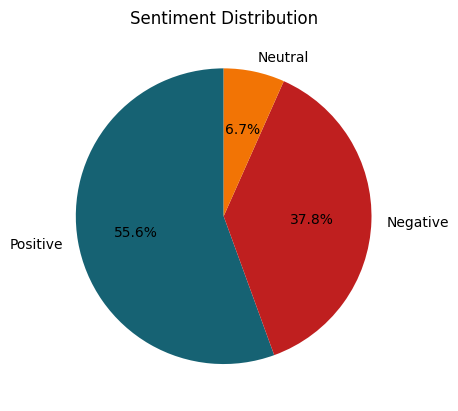

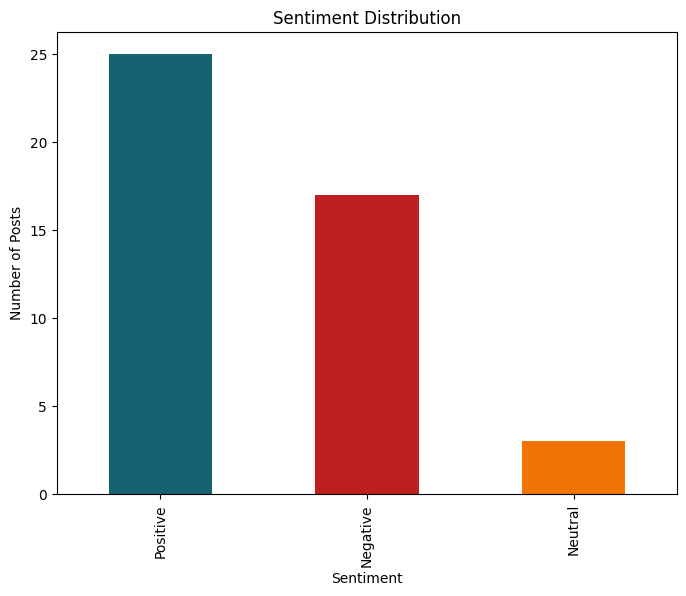

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

#Bar Chart for Sentiment Distribution
sentiment_counts = df['sentiment'].value_counts()  # Count sentiments using Pandas


# Pie chart using Pandas
sentiment_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90, colors=["#166273", "#BF1F1F", "#F27405"], title="Sentiment Distribution")
plt.ylabel("")  # Remove y-axis label
plt.show()


# Plot bar chart
sentiment_counts.plot(kind='bar', color=['#166273', '#BF1F1F', '#F27405'], figsize=(8, 6))
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.show()



#Brand Insights

In [ ]:
# Frequent keywords in positive and negative posts
from collections import Counter

def get_top_keywords(df, sentiment):
    words = " ".join(df[df["sentiment"] == sentiment]["processed_content"]).split()
    return Counter(words)

positive_keywords = get_top_keywords(df, "Positive")
negative_keywords = get_top_keywords(df, "Negative")

print("Top Positive Keywords:", positive_keywords)
print("Top Negative Keywords:", negative_keywords)


Top Positive Keywords: Counter({'dont': 19, 'paid': 16, 'starbucks': 13, 'like': 12, 'get': 11, 'partner': 11, 'company': 10, 'would': 9, 'make': 9, 'know': 9, 'tip': 8, 'didnt': 7, 'pay': 7, 'today': 7, 'keep': 7, 'store': 7, 'flavor': 7, 'house': 7, 'people': 6, 'even': 6, 'time': 6, 'anyone': 6, 'ive': 6, 'different': 6, 'one': 6, 'made': 6, 'many': 5, 'best': 5, 'care': 5, 'shift': 5, 'said': 5, 'work': 5, 'youre': 5, 'week': 5, 'sure': 5, 'something': 5, 'lol': 5, 'im': 5, 'money': 4, 'show': 4, 'good': 4, 'lot': 4, 'want': 4, 'let': 4, 'cant': 4, 'food': 4, 'everyone': 4, 'well': 4, 'u': 4, 'wednesday': 4, 'still': 4, 'first': 4, 'use': 4, 'life': 4, 'year': 4, 'see': 3, 'yeah': 3, 'either': 3, 'manager': 3, 'miss': 3, 'got': 3, 'trying': 3, 'always': 3, 'enough': 3, 'say': 3, 'back': 3, 'yet': 3, 'okay': 3, 'due': 3, 'rent': 3, 'day': 3, 'plan': 3, 'around': 3, 'last': 3, 'held': 3, 'customer': 3, 'change': 3, 'jar': 3, 'usually': 3, 'id': 3, 'found': 3, 'cup': 3, 'please': 3, '

#Recommendations:

Enhance Customer and Employee Experience:
Improving customer service by training staff for better communication, order accuracy, and quicker issue resolution.

Leverage Strengths and Address Operational Gaps:
Build on customer appreciation for flavors and store ambiance by introducing new seasonal drinks . Streamline operations to reduce delays, improve cleanliness, and ensure consistent product quality.

